In [ ]:
import numpy as np # to handle multidimensional array
import pandas as pd
from sklearn.model_selection import train_test_split# model_selection is a module and train_test_split is a class
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# cross validation == k fold
file_path="/content/home_dataset.csv"
data=pd.read_csv(file_path)# reads all data at a time
data.head(10)



,HouseSize,HousePrice
0,793,1300000
1,2477,3700000
2,1263,1480000
3,1291,2380000
4,603,955000
5,1655,2130000
6,1071,1300000
7,1877,2700000
8,1610,2650000
9,3058,2850000


In [ ]:
# data prepration we are extraxting two colums and converting them into Numpy array
house_sizes=data['HouseSize'].values
house_prize=data['HousePrice'].values

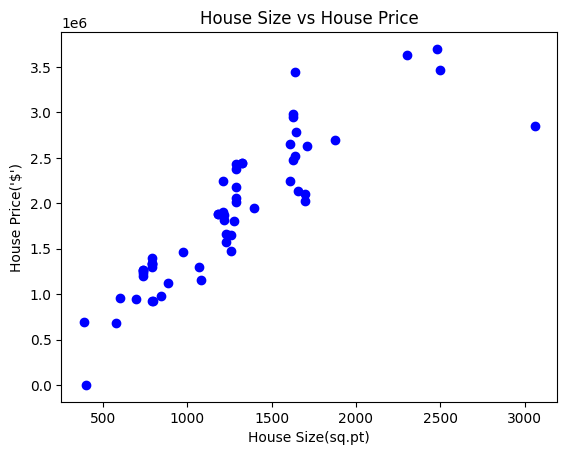

In [ ]:
plt.scatter(house_sizes,house_prize,marker='o',color="blue")
plt.title("House Size vs House Price")
plt.xlabel("House Size(sq.pt)")
plt.ylabel("House Price('$')")
plt.show()

<Axes: >

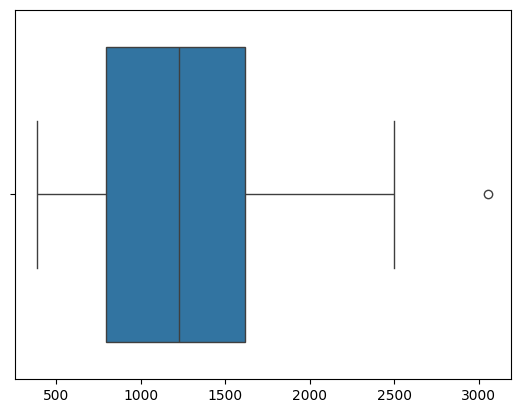

In [ ]:
# data is sort of linear
# it has definately outliers
sns.boxplot(x=house_sizes)

<Axes: >

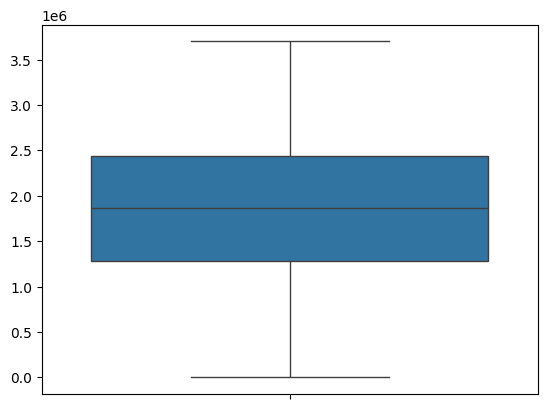

In [ ]:
#sns.boxplot(y=house_prize)
#

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(house_sizes,house_prize,test_size=0.2,random_state=42)
# we use it to vaidate data.
# random state tells the function how to handle randomness
# handles learning of model

In [ ]:
print(x_train.shape)# if shape=(6,0) --> 1D (a flat list)
print(x_test.shape)
#1 D needs reshape before sk learn or when data is dynamic

(47,)
(12,)


In [ ]:
x_train=x_train.reshape(-1,1)# converts !D data into 2D , helps sk learn to fit model
x_test=x_test.reshape(-1,1)

In [ ]:
# create and train model
model=LinearRegression()
model.fit(x_train,y_train)#.fit() tells the model to learn from the training data
#by adjusting its parameters to minimize error.#


LinearRegression()

In [ ]:
# get residuals
X_name=data[['HouseSize']]
Y_name=data['HousePrice']
predictions=model.predict(X_name)# x= house size
residuals=Y_name-predictions


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


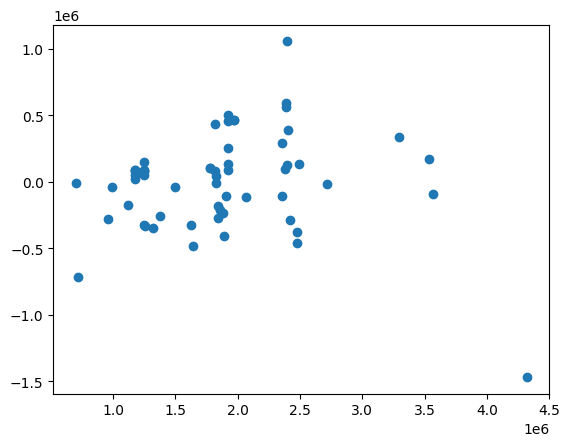

In [ ]:
# plot resudual and prediction
plt.scatter(predictions,residuals)

In [ ]:
# breusch pagan test
import statsmodels.stats.diagnostic as diag
import statsmodels.api as sm
# fit model with statmodels
X_const=sm.add_constant(X_name)
ols_model=sm.OLS(Y_name,X_const) # Define OLS model
ols_results = ols_model.fit() # Fit the OLS model to get results
#run test
bp_test=diag.het_breuschpagan(ols_results.resid,ols_results.model.exog)
labels=['LM statistic','LM-test p-value','F-statistic','F-test p-value']
for label , value in zip(labels,bp_test):
  print(f"{label}:{value:.4f}")

LM statistic:11.7153
LM-test p-value:0.0006
F-statistic:14.1224
F-test p-value:0.0004


In [ ]:
# both p values are less than 0.05
#if LM-test p-value:0.0006 <0.05 reject H0) hetrosedastic problem---> variance of residuals is not constant accross house prize (yout model has problem)
# apply np.log(Y_name) to fix it
# Lm= chi square test, F_test
# your model need correction before  making correct predictions
""" as house size increases the models errors also increases -- meaning the model is less accurate for bigger house than smaller ones"""
#Sol: best sol is log transformation for house pricing data


import numpy as np
# transform Y (house prize)
Y_log=np.log(Y_name)
#refit model with log Y
X_const=sm.add_constant(X_name)
ols_model=sm.OLS(Y_log,X_const) # Define OLS model
ols_results = ols_model.fit() # Fit the OLS model to get results
# rerun breusch pagan
bp_test=diag.het_breuschpagan(ols_results.resid,ols_results.model.exog)
labels=['LM statistic','LM-test p-value','F-statistic','F-test p-value']
for label , value in zip(labels,bp_test):
  print(f"{label}:{value:.4f}")

LM statistic:2.5876
LM-test p-value:0.1077
F-statistic:2.6145
F-test p-value:0.1114


In [ ]:
# now variance is constant
# now check performance of model
# R-squared test
print(ols_results.summary())

                            OLS Regression Results                            
Dep. Variable:             HousePrice   R-squared:                       0.154
Model:                            OLS   Adj. R-squared:                  0.139
Method:                 Least Squares   F-statistic:                     10.35
Date:                Fri, 06 Mar 2026   Prob (F-statistic):            0.00214
Time:                        04:39:51   Log-Likelihood:                -116.67
No. Observations:                  59   AIC:                             237.3
Df Residuals:                      57   BIC:                             241.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         12.3224      0.610     20.198      0.0

In [ ]:
# make predictions
# pridict log price

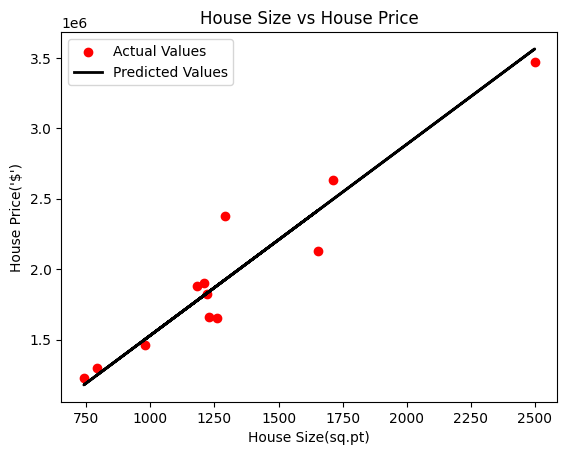

In [ ]:
#predictions=model.predict(x_test)# x= house size
# visualize it
plt.scatter(x_test,y_test,marker='o',color="red",label='Actual Values')
plt.plot(x_test,predictions,color='black',linewidth=2,label='Predicted Values')
plt.title("House Size vs House Price")
plt.xlabel("House Size(sq.pt)")
plt.ylabel("House Price('$')")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error,r2_score
print("Coefficients :",model.coef_)#  calulates m (slope )
mse = mean_squared_error(y_test, predictions)# error predict and actual
print(f"Mean Squared error :{mse:.2f}")
r_score = r2_score(y_test, predictions)
print(f"Coefficient of determination :{r_score:.2f}")# calculates errro

Coefficients : [1355.34466659]
Mean Squared error :35702944443.25
Coefficient of determination :0.90


In [ ]:
# load the diabetes dataset
from sklearn import datasets, linear_model

In [ ]:
diabetes_X,diabetes_y=datasets.load_diabetes(return_X_y=True)

In [ ]:
import pandas as pd

diabetes_X_df = pd.DataFrame(diabetes_X)
display(diabetes_X_df.head())

display(pd.Series(diabetes_y).head())

,0
0,0.061696
1,-0.051474
2,0.044451
3,-0.011595
4,-0.036385


,0
0,151.0
1,75.0
2,141.0
3,206.0
4,135.0


In [ ]:
# use only one feature
diabetes_X=diabetes_X[:,np.newaxis,2]

In [ ]:
#split the data
diabetes_X_train=diabetes_X[:-20]
diabetes_X_test=diabetes_X[-20:]

In [ ]:
#split
diabetes_y_train=diabetes_y[:-20]
diabetes_y_test=diabetes_y[-20:]

In [ ]:
red=linear_model.LinearRegression()
red.fit(diabetes_X_train,diabetes_y_train)

LinearRegression()

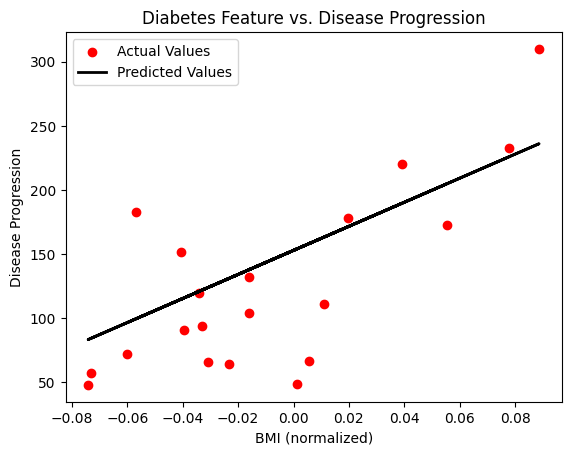

In [ ]:
diabetes_predictions = red.predict(diabetes_X_test)

plt.scatter(diabetes_X_test, diabetes_y_test, color='red', label='Actual Values')
plt.plot(diabetes_X_test, diabetes_predictions, color='black', linewidth=2, label='Predicted Values')
plt.title('Diabetes Feature vs. Disease Progression')
plt.xlabel('BMI (normalized)')
plt.ylabel('Disease Progression')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error,r2_score
print("Coefficients :",model.coef_)
mse = mean_squared_error(y_test, predictions)# error predict and actual
print(f"Mean Squared error :{mse:.2f}")
r_score = r2_score(y_test, predictions)
print(f"Coefficient of determination :{r_score:.2f}")

Coefficients : [1355.34466659]
Mean Squared error :35702944443.25
Coefficient of determination :0.90
